<a href="https://colab.research.google.com/github/badigantihemanjali-pixel/health-insurance-prediction/blob/main/health_insurance_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

url = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv"
data = pd.read_csv(url)

data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None

Missing values:
 age         0
sex         0
bmi         0
children    0
smoker      0
reg

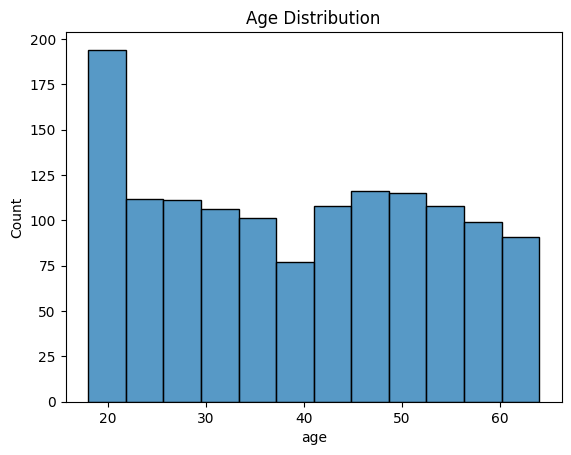

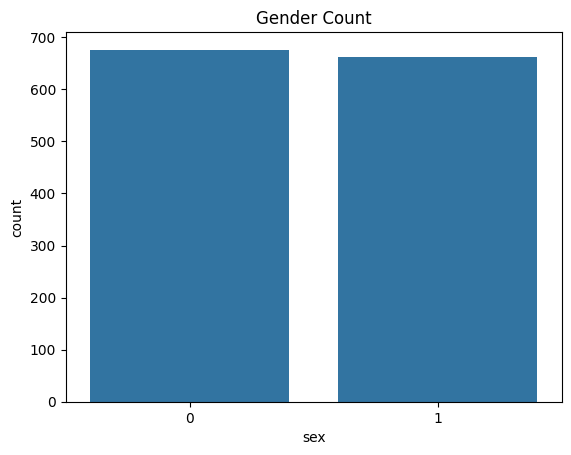

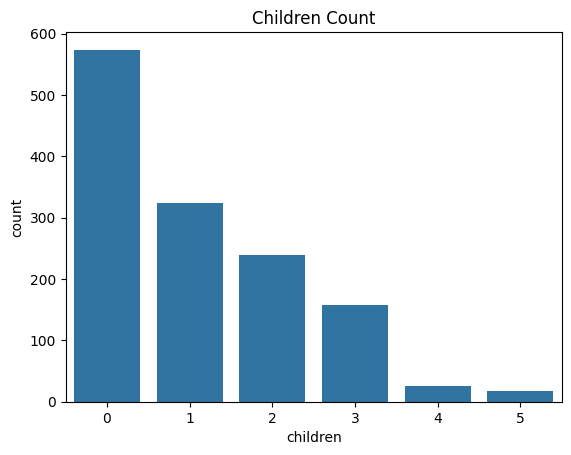

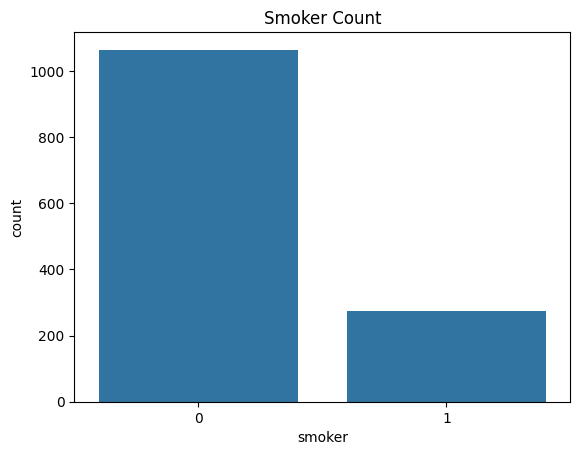

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics

# Load dataset
data = pd.read_csv(url)

# Display dataset
print(data.head())
print(data.info())

# Check missing values
print("\nMissing values:\n", data.isnull().sum())

# Describe data
print("\nData Description:\n", data.describe())

# Encoding categorical data
data['sex'] = data['sex'].map({'male': 0, 'female': 1})
data['smoker'] = data['smoker'].map({'yes': 1, 'no': 0})

# One-hot encoding for region
data = pd.get_dummies(data, columns=['region'], drop_first=True)

# Split features and target
X = data.drop('charges', axis=1)
y = data['charges']

print("\nFeatures:\n", X.head())
print("\nTarget:\n", y.head())

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=2
)

# Model
model = LinearRegression()
model.fit(X_train, y_train)

# Prediction
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

# Evaluation
print("\nTrain R2 Score:", metrics.r2_score(y_train, train_pred))
print("Test R2 Score:", metrics.r2_score(y_test, test_pred))

# Visualization
sns.histplot(data['age'])
plt.title("Age Distribution")
plt.show()

sns.countplot(x='sex', data=data)
plt.title("Gender Count")
plt.show()

sns.countplot(x='children', data=data)
plt.title("Children Count")
plt.show()

sns.countplot(x='smoker', data=data)
plt.title("Smoker Count")
plt.show()